# Election Prediction Project
## Notebook 04 — Model Evaluation, Error Analysis and Visualization

### This notebook presents:
*   A performance comparison across all tested models.
*   Overall performance of the selected model.
*   Performance breakdown by voting bloc.
*   Actual vs. Predicted plots.
*   Error analysis by locality type.
*   Identification of the top 10 localities with the highest prediction errors.
*   Error bias analysis (overestimation vs. underestimation).
*   Metrics weighted by the number of valid votes, where available.
*   Discussion of model limitations and future recommendations.

### input

- `reports/model_comparison.csv`
- `reports/model_comparison_by_target.csv`
- `processed_data/validation_predictions_selected_model.csv`
- `reports/modeling_summary.json`
- `models/final_model_bundle.joblib`

### output

- `reports/evaluation_summary.csv`
- `reports/error_analysis_by_locality.csv`
- `reports/error_summary_by_group.csv`
- `reports/error_summary_by_group_and_target.csv`
- `reports/evaluation_summary.json`
- גרפים בתיקייה `reports/figures/`


## 1. Imports and project configuration

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 200)

TARGET_COLUMNS = [
    "Right_pct",
    "Center_Left_pct",
    "Haredi_pct",
    "Arab_pct",
]

TARGET_LABELS = {
    "Right_pct": "Right",
    "Center_Left_pct": "Center-Left",
    "Haredi_pct": "Haredi",
    "Arab_pct": "Arab",
}

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Repository-relative configuration (run notebooks from the notebooks/ folder):
# all paths stay relative, so the project runs on any machine straight after cloning.
REPO_ROOT = Path('..')

PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
REPORTS_DIR = REPO_ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
MODELS_DIR = REPO_ROOT / 'models'

MODEL_COMPARISON_PATH = REPORTS_DIR / 'model_comparison.csv'
TARGET_COMPARISON_PATH = REPORTS_DIR / 'model_comparison_by_target.csv'
VALIDATION_PREDICTIONS_PATH = (
    PROCESSED_DIR / 'validation_predictions_selected_model.csv'
)
MODELING_SUMMARY_PATH = REPORTS_DIR / 'modeling_summary.json'
MODEL_BUNDLE_PATH = MODELS_DIR / 'final_model_bundle.joblib'

EVALUATION_SUMMARY_CSV_PATH = REPORTS_DIR / 'evaluation_summary.csv'
LOCALITY_ERROR_PATH = REPORTS_DIR / 'error_analysis_by_locality.csv'
GROUP_ERROR_PATH = REPORTS_DIR / 'error_summary_by_group.csv'
GROUP_TARGET_ERROR_PATH = REPORTS_DIR / 'error_summary_by_group_and_target.csv'
EVALUATION_SUMMARY_JSON_PATH = REPORTS_DIR / 'evaluation_summary.json'

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Model comparison: {MODEL_COMPARISON_PATH}')
print(f'Validation predictions: {VALIDATION_PREDICTIONS_PATH}')


Model comparison: ..\reports\model_comparison.csv
Validation predictions: ..\data\processed\validation_predictions_selected_model.csv


## 2. Load and validate evaluation artifacts

In [3]:
required_files = [
    MODEL_COMPARISON_PATH,
    TARGET_COMPARISON_PATH,
    VALIDATION_PREDICTIONS_PATH,
    MODELING_SUMMARY_PATH,
    MODEL_BUNDLE_PATH,
]

missing_files = [
    path
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following required files were not found:\n"
        + "\n".join(
            str(path)
            for path in missing_files
        )
        + "\nRun Notebook 03 before continuing."
    )

model_comparison_df = pd.read_csv(
    MODEL_COMPARISON_PATH
)

target_comparison_df = pd.read_csv(
    TARGET_COMPARISON_PATH
)

predictions_df = pd.read_csv(
    VALIDATION_PREDICTIONS_PATH,
    low_memory=False
)

with open(
    MODELING_SUMMARY_PATH,
    "r",
    encoding="utf-8"
) as file:
    modeling_summary = json.load(file)

model_bundle = joblib.load(
    MODEL_BUNDLE_PATH
)

selected_model_name = modeling_summary[
    "selected_model"
]

print(f"Selected model: {selected_model_name}")
print(f"Validation election: {modeling_summary['validation_election']}")
print(f"Prediction rows: {len(predictions_df)}")

display(model_comparison_df.head())
display(target_comparison_df.head())
display(predictions_df.head())


Selected model: Segmented CLR
Validation election: Knesset_25
Prediction rows: 226


,Model,Overall_MAE,Overall_R2
0,Segmented CLR,4.635148,0.898999
1,Segmented CLR + Druze Indicator,4.644562,0.896841
2,XGBoost + Locality Types — Post-hoc Normalized,4.899773,0.904052
3,CLR XGBoost — Demographic + Locality Types,4.974797,0.882351
4,XGBoost — Demographic + Locality Types,5.114792,0.887692


,Model,Target,MAE,R2
0,Linear Regression — Demographic,Right_pct,13.636163,0.314057
1,Linear Regression — Demographic,Center_Left_pct,15.118457,0.453233
2,Linear Regression — Demographic,Haredi_pct,8.847255,0.473708
3,Linear Regression — Demographic,Arab_pct,9.387842,0.873075
4,Random Forest — Demographic,Right_pct,7.019063,0.828004


,locality_symbol,שם יישוב,year,target_election,valid_votes,type_Arab/Non-Jewish,type_Cities,type_Kibbutzim,type_Moshavim,type_other,type_Druze_Majority,Right_pct,Center_Left_pct,Haredi_pct,Arab_pct,Predicted_Right_pct,Absolute_Error_Right_pct,Predicted_Center_Left_pct,Absolute_Error_Center_Left_pct,Predicted_Haredi_pct,Absolute_Error_Haredi_pct,Predicted_Arab_pct,Absolute_Error_Arab_pct,Mean_Absolute_Error,Predicted_Total
0,1015,מבשרת ציון,2022,Knesset_25,14051,0,1,0,0,0,0,45.163610,48.212873,6.220784,0.402733,45.314885,0.151275,48.399005,0.186132,6.103816,0.116968,0.182294,0.220439,0.168704,100.0
1,1020,אור עקיבא,2022,Knesset_25,10879,0,1,0,0,0,0,60.863497,27.263422,11.714897,0.158184,65.252569,4.389073,25.207416,2.056006,9.471061,2.243836,0.068953,0.089230,2.194536,100.0
2,1031,שדרות,2022,Knesset_25,15242,0,1,0,0,0,0,67.769200,18.780780,13.223746,0.226274,66.969833,0.799367,22.939826,4.159046,9.979335,3.244411,0.111006,0.115269,2.079523,100.0
3,1034,קריית מלאכי,2022,Knesset_25,12591,0,1,0,0,0,0,64.807522,9.893113,25.235072,0.064293,65.756842,0.949319,13.562414,3.669301,20.624131,4.610941,0.056613,0.007680,2.309310,100.0
4,1054,תל שבע,2022,Knesset_25,5766,1,0,0,0,0,0,1.150227,1.376786,0.191704,97.281283,3.348151,2.197924,3.167243,1.790457,0.177308,0.014396,93.307298,3.973985,1.994191,100.0


In [4]:
PREDICTED_COLUMNS = [
    f"Predicted_{target}"
    for target in TARGET_COLUMNS
]

ABSOLUTE_ERROR_COLUMNS = [
    f"Absolute_Error_{target}"
    for target in TARGET_COLUMNS
]

required_prediction_columns = [
    "locality_symbol",
    *TARGET_COLUMNS,
    *PREDICTED_COLUMNS,
    *ABSOLUTE_ERROR_COLUMNS,
    "Mean_Absolute_Error",
    "Predicted_Total",
]

missing_prediction_columns = [
    column
    for column in required_prediction_columns
    if column not in predictions_df.columns
]

if missing_prediction_columns:
    raise ValueError(
        f"Missing prediction columns: {missing_prediction_columns}"
    )

for column in (
    TARGET_COLUMNS
    + PREDICTED_COLUMNS
    + ABSOLUTE_ERROR_COLUMNS
    + ["Mean_Absolute_Error", "Predicted_Total"]
):
    predictions_df[column] = pd.to_numeric(
        predictions_df[column],
        errors="coerce"
    )

if predictions_df[
    TARGET_COLUMNS + PREDICTED_COLUMNS
].isna().any().any():
    raise ValueError(
        "Missing actual or predicted target values were found."
    )

if not np.allclose(
    predictions_df[TARGET_COLUMNS].sum(axis=1),
    100,
    atol=1e-6
):
    raise ValueError(
        "Actual target percentages do not sum to 100%."
    )

if not np.allclose(
    predictions_df[PREDICTED_COLUMNS].sum(axis=1),
    100,
    atol=1e-4
):
    raise ValueError(
        "Predicted percentages do not sum to 100%."
    )

if (
    predictions_df[PREDICTED_COLUMNS]
    .lt(0)
    .any()
    .any()
):
    raise ValueError(
        "Negative predicted percentages were found."
    )

print("Evaluation artifacts passed all quality checks.")
print(
    f"Minimum predicted sum: "
    f"{predictions_df['Predicted_Total'].min():.6f}"
)
print(
    f"Maximum predicted sum: "
    f"{predictions_df['Predicted_Total'].max():.6f}"
)


Evaluation artifacts passed all quality checks.
Minimum predicted sum: 100.000000
Maximum predicted sum: 100.000000


## 3. Overall comparison between modeling approaches

**הערה:** טבלת ההשוואה מציגה את שלב **בחירת המודל** — ביצועים על כנסת 24 (ולידציה). המדדים הסופיים המדווחים של המודל הנבחר מחושבים בהמשך המחברת מקובץ תחזיות ה**טסט** (כנסת 25).

In [5]:
model_comparison_sorted = (
    model_comparison_df
    .sort_values(
        "Overall_MAE",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    model_comparison_sorted
    .round(3)
)

selected_model_row = (
    model_comparison_sorted.loc[
        model_comparison_sorted["Model"]
        .eq(selected_model_name)
    ]
)

if selected_model_row.empty:
    raise ValueError(
        "The selected model was not found "
        "in the comparison table."
    )

selected_model_row = selected_model_row.iloc[0]

print(
    f"Selected model MAE: "
    f"{selected_model_row['Overall_MAE']:.3f}"
)
print(
    f"Selected model R2: "
    f"{selected_model_row['Overall_R2']:.3f}"
)


,Model,Overall_MAE,Overall_R2
0,Segmented CLR,4.635,0.899
1,Segmented CLR + Druze Indicator,4.645,0.897
2,XGBoost + Locality Types — Post-hoc Normalized,4.900,0.904
3,CLR XGBoost — Demographic + Locality Types,4.975,0.882
4,XGBoost — Demographic + Locality Types,5.115,0.888
5,XGBoost — Demographic,5.384,0.869
6,Random Forest — Demographic,5.468,0.867
7,MLP (CLR) — Neural Baseline,6.663,0.812
8,Linear Regression — Demographic,11.747,0.529


Selected model MAE: 4.635
Selected model R2: 0.899


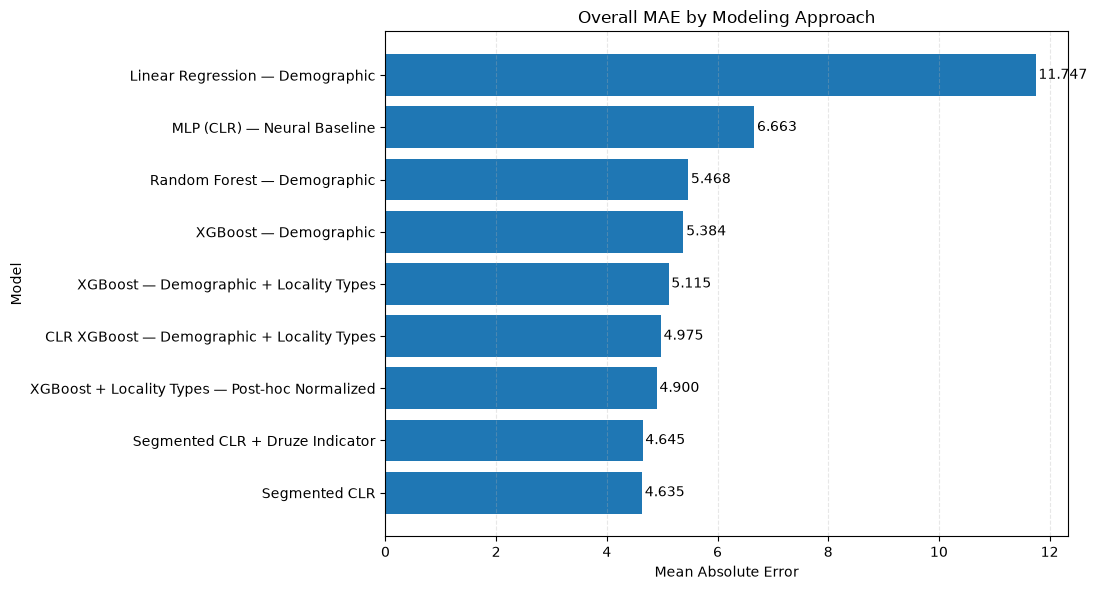

In [6]:
plt.figure(figsize=(11, 6))

bars = plt.barh(
    model_comparison_sorted["Model"],
    model_comparison_sorted["Overall_MAE"]
)

plt.title("Overall MAE by Modeling Approach")
plt.xlabel("Mean Absolute Error")
plt.ylabel("Model")

for bar, value in zip(
    bars,
    model_comparison_sorted["Overall_MAE"]
):
    plt.text(
        value + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "model_comparison_mae.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


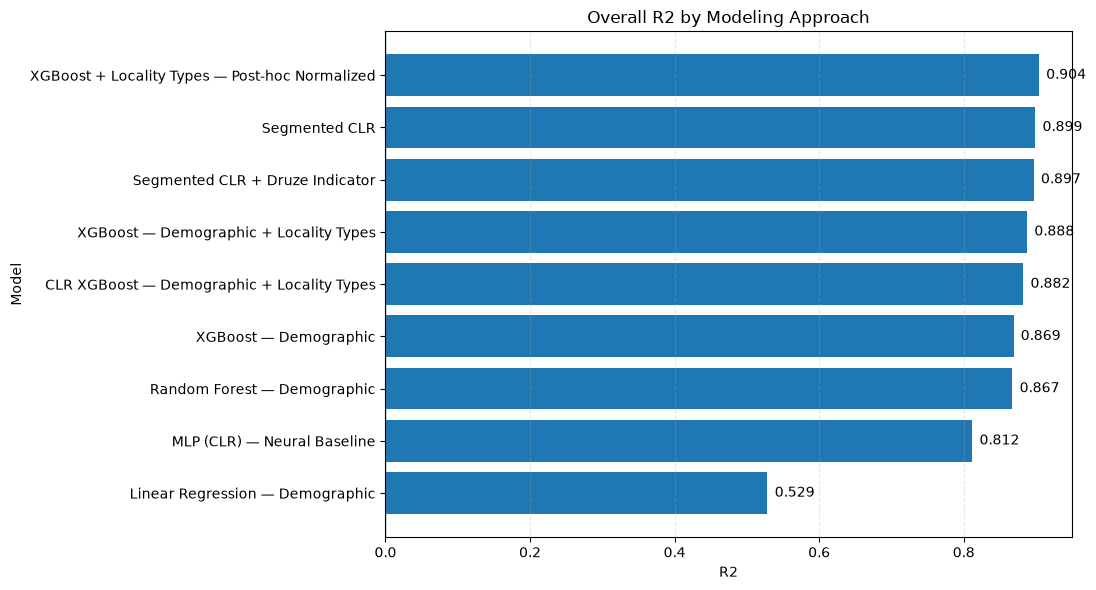

In [7]:
model_r2_sorted = (
    model_comparison_df
    .sort_values(
        "Overall_R2",
        ascending=True
    )
    .reset_index(drop=True)
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    model_r2_sorted["Model"],
    model_r2_sorted["Overall_R2"]
)

plt.title("Overall R2 by Modeling Approach")
plt.xlabel("R2")
plt.ylabel("Model")

for bar, value in zip(
    bars,
    model_r2_sorted["Overall_R2"]
):
    horizontal_offset = 0.01 if value >= 0 else -0.08

    plt.text(
        value + horizontal_offset,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.axvline(
    0,
    linewidth=1
)

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "model_comparison_r2.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


## 4. Selected model performance by voting block — selection phase (Knesset 24)

(פירוק הטסט הסופי על כנסת 25 מחושב בסעיף 12 מקובץ התחזיות.)

In [8]:
selected_target_results = (
    target_comparison_df.loc[
        target_comparison_df["Model"]
        .eq(selected_model_name)
    ]
    .copy()
)

if len(selected_target_results) != len(TARGET_COLUMNS):
    raise ValueError(
        "The target-level results for the selected model "
        "are incomplete."
    )

selected_target_results["Target_Label"] = (
    selected_target_results["Target"]
    .map(TARGET_LABELS)
)

selected_target_results = (
    selected_target_results
    .set_index("Target")
    .loc[TARGET_COLUMNS]
    .reset_index()
)

display(
    selected_target_results[
        [
            "Target",
            "MAE",
            "R2",
        ]
    ]
    .round(3)
)


,Target,MAE,R2
0,Right_pct,6.917,0.852
1,Center_Left_pct,6.881,0.850
2,Haredi_pct,2.360,0.914
3,Arab_pct,2.383,0.980


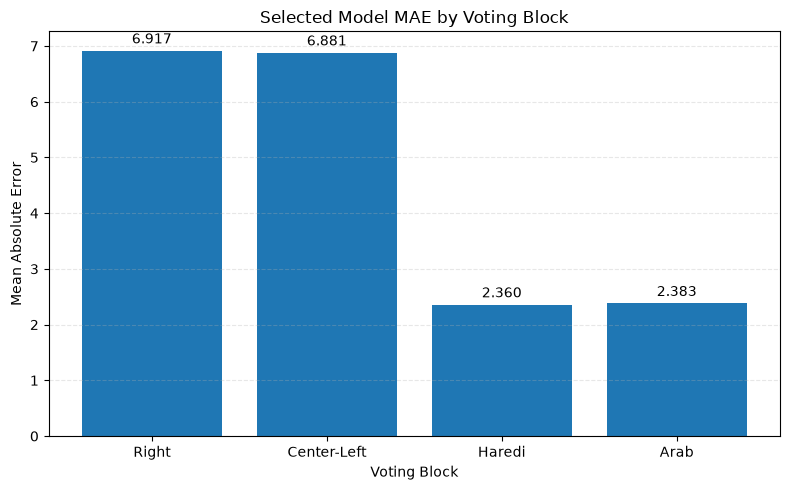

In [9]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    selected_target_results["Target_Label"],
    selected_target_results["MAE"]
)

plt.title("Selected Model MAE by Voting Block")
plt.xlabel("Voting Block")
plt.ylabel("Mean Absolute Error")

for bar, value in zip(
    bars,
    selected_target_results["MAE"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.07,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "selected_model_mae_by_target.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


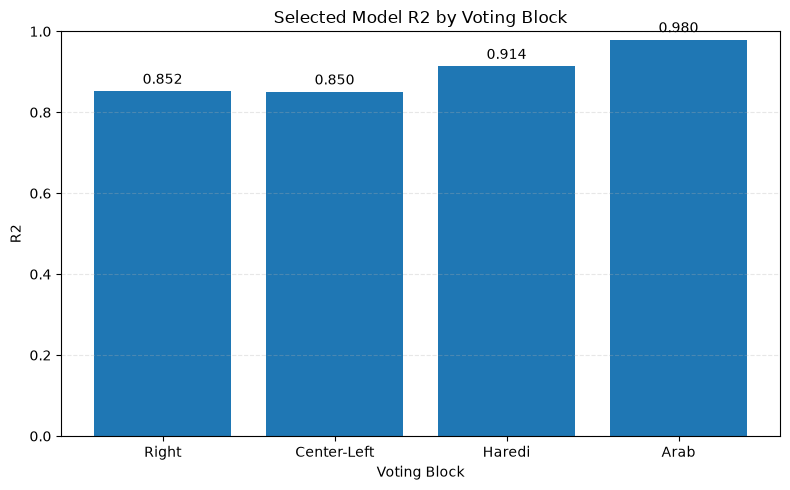

In [10]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    selected_target_results["Target_Label"],
    selected_target_results["R2"]
)

plt.title("Selected Model R2 by Voting Block")
plt.xlabel("Voting Block")
plt.ylabel("R2")
plt.ylim(
    min(0, selected_target_results["R2"].min() - 0.05),
    1.0
)

for bar, value in zip(
    bars,
    selected_target_results["R2"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "selected_model_r2_by_target.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


## 5. Actual versus predicted values



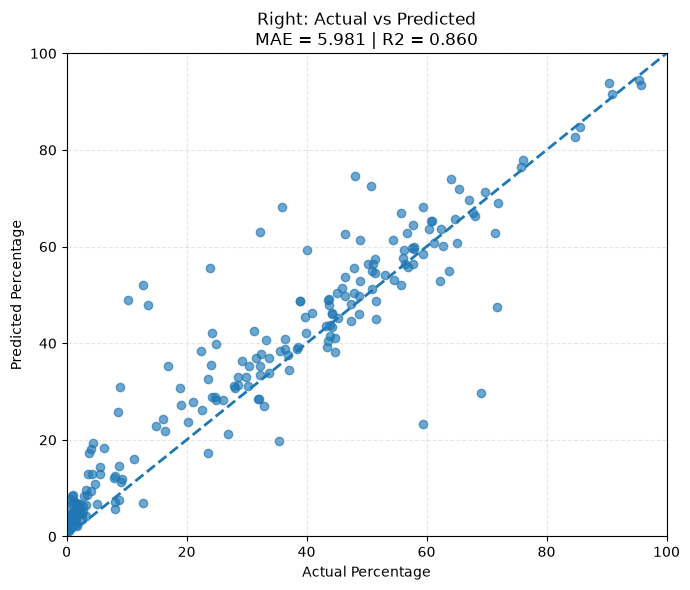

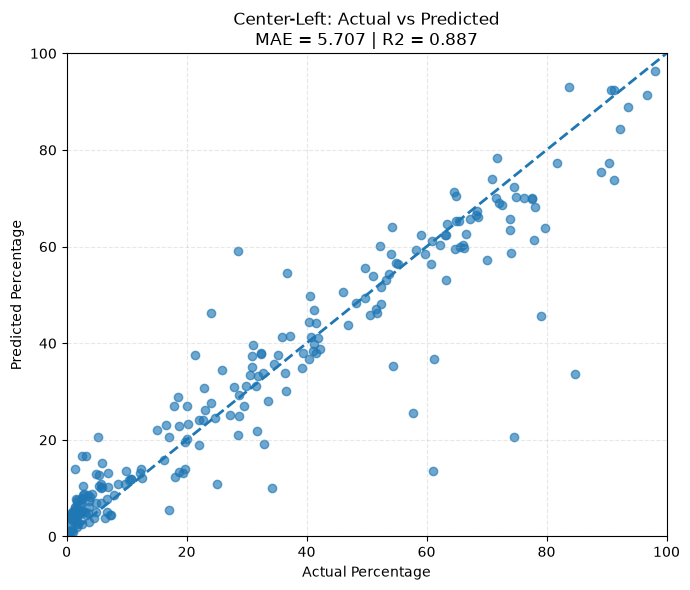

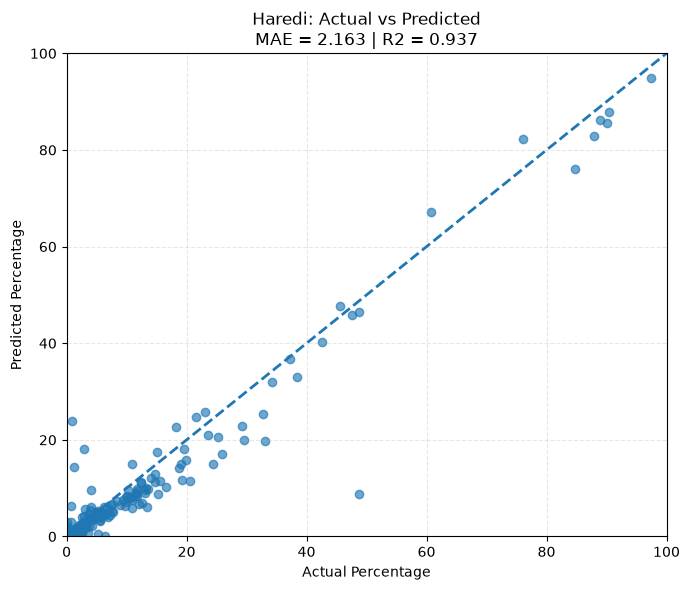

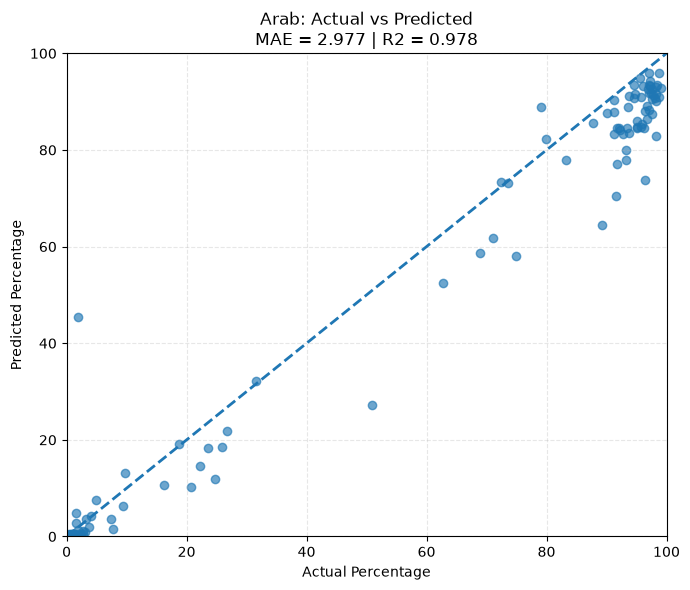

In [11]:
for target in TARGET_COLUMNS:
    actual_values = predictions_df[target]
    predicted_values = predictions_df[
        f"Predicted_{target}"
    ]

    target_mae = mean_absolute_error(
        actual_values,
        predicted_values
    )

    target_r2 = r2_score(
        actual_values,
        predicted_values
    )

    plt.figure(figsize=(7, 6))

    plt.scatter(
        actual_values,
        predicted_values,
        alpha=0.65
    )

    plt.plot(
        [0, 100],
        [0, 100],
        linestyle="--",
        linewidth=2
    )

    plt.xlim(0, 100)
    plt.ylim(0, 100)

    plt.title(
        f"{TARGET_LABELS[target]}: Actual vs Predicted\n"
        f"MAE = {target_mae:.3f} | R2 = {target_r2:.3f}"
    )
    plt.xlabel("Actual Percentage")
    plt.ylabel("Predicted Percentage")
    plt.grid(linestyle="--", alpha=0.3)
    plt.tight_layout()

    output_name = (
        f"actual_vs_predicted_{target}.png"
    )

    plt.savefig(
        FIGURES_DIR / output_name,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()


## 6. Build a complete locality-level error table

In [12]:
error_df = predictions_df.copy()

for target in TARGET_COLUMNS:
    predicted_column = f"Predicted_{target}"
    signed_error_column = f"Signed_Error_{target}"
    absolute_error_column = f"Absolute_Error_{target}"

    error_df[signed_error_column] = (
        error_df[predicted_column]
        - error_df[target]
    )

    error_df[absolute_error_column] = np.abs(
        error_df[signed_error_column]
    )

error_df["Mean_Absolute_Error"] = (
    error_df[
        ABSOLUTE_ERROR_COLUMNS
    ]
    .mean(axis=1)
)

error_df["Maximum_Error"] = (
    error_df[
        ABSOLUTE_ERROR_COLUMNS
    ]
    .max(axis=1)
)

largest_error_indices = (
    error_df[
        ABSOLUTE_ERROR_COLUMNS
    ]
    .to_numpy()
    .argmax(axis=1)
)

error_df["Largest_Error_Target"] = [
    TARGET_COLUMNS[index]
    for index in largest_error_indices
]

name_candidates = [
    "שם יישוב",
    "שם ישוב",
    "locality_name",
]

locality_name_column = next(
    (
        column
        for column in name_candidates
        if column in error_df.columns
    ),
    None
)

if locality_name_column is None:
    locality_name_column = "locality_symbol"

error_df[locality_name_column] = (
    error_df[locality_name_column]
    .fillna(
        error_df["locality_symbol"]
        .astype(str)
    )
)

print(
    "Locality-level error table created:",
    error_df.shape
)

display(
    error_df[
        [
            locality_name_column,
            "Mean_Absolute_Error",
            "Largest_Error_Target",
            "Maximum_Error",
        ]
    ]
    .sort_values(
        "Mean_Absolute_Error",
        ascending=False
    )
    .head(10)
    .round(3)
)


Locality-level error table created: (226, 31)


,שם יישוב,Mean_Absolute_Error,Largest_Error_Target,Maximum_Error
73,בת שלמה,27.297,Center_Left_pct,53.999
27,חצבה,26.191,Center_Left_pct,51.165
39,שדה משה,23.765,Center_Left_pct,47.530
101,מסעדה,21.691,Arab_pct,43.383
72,עוצם,20.045,Haredi_pct,40.089
141,סאג'ור,19.678,Right_pct,39.356
103,ע'ג'ר,19.678,Right_pct,38.851
26,כסרא-סמיע,18.632,Right_pct,34.278
104,עין קנייא,15.451,Right_pct,30.866
219,טובא-זנגרייה,12.343,Arab_pct,24.686


## 7. Error analysis by mutually exclusive locality group

In [13]:
classification_columns = [
    "type_Arab/Non-Jewish",
    "type_Cities",
    "type_Kibbutzim",
    "type_Moshavim",
    "type_other",
    "type_Druze_Majority",
]

missing_classification_columns = [
    column
    for column in classification_columns
    if column not in error_df.columns
]

if missing_classification_columns:
    raise ValueError(
        f"Missing classification columns: "
        f"{missing_classification_columns}"
    )

conditions = [
    error_df["type_Druze_Majority"].eq(1),

    (
        error_df["type_Arab/Non-Jewish"].eq(1)
        & error_df["type_Druze_Majority"].eq(0)
    ),

    error_df["type_Moshavim"].eq(1),
    error_df["type_Kibbutzim"].eq(1),
    error_df["type_Cities"].eq(1),
    error_df["type_other"].eq(1),
]

group_names = [
    "Druze Majority",
    "Arab/Non-Jewish — Non-Druze",
    "Moshavim",
    "Kibbutzim",
    "Cities",
    "Other",
]

error_df["Analysis_Group"] = np.select(
    conditions,
    group_names,
    default="Unclassified"
)

group_error_summary = (
    error_df
    .groupby(
        "Analysis_Group",
        as_index=False
    )
    .agg(
        Number_of_Rows=(
            "locality_symbol",
            "size"
        ),
        Number_of_Localities=(
            "locality_symbol",
            "nunique"
        ),
        Mean_MAE=(
            "Mean_Absolute_Error",
            "mean"
        ),
        Median_MAE=(
            "Mean_Absolute_Error",
            "median"
        ),
        Maximum_MAE=(
            "Mean_Absolute_Error",
            "max"
        ),
    )
    .sort_values(
        "Mean_MAE",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    group_error_summary
    .round(3)
)


,Analysis_Group,Number_of_Rows,Number_of_Localities,Mean_MAE,Median_MAE,Maximum_MAE
0,Druze Majority,15,15,10.704,8.761,21.691
1,Moshavim,13,13,10.627,7.051,27.297
2,Arab/Non-Jewish — Non-Druze,66,66,4.358,3.882,19.678
3,Cities,120,120,2.800,2.314,12.124
4,Other,5,5,2.451,2.705,4.384
5,Kibbutzim,7,7,2.305,2.669,4.620


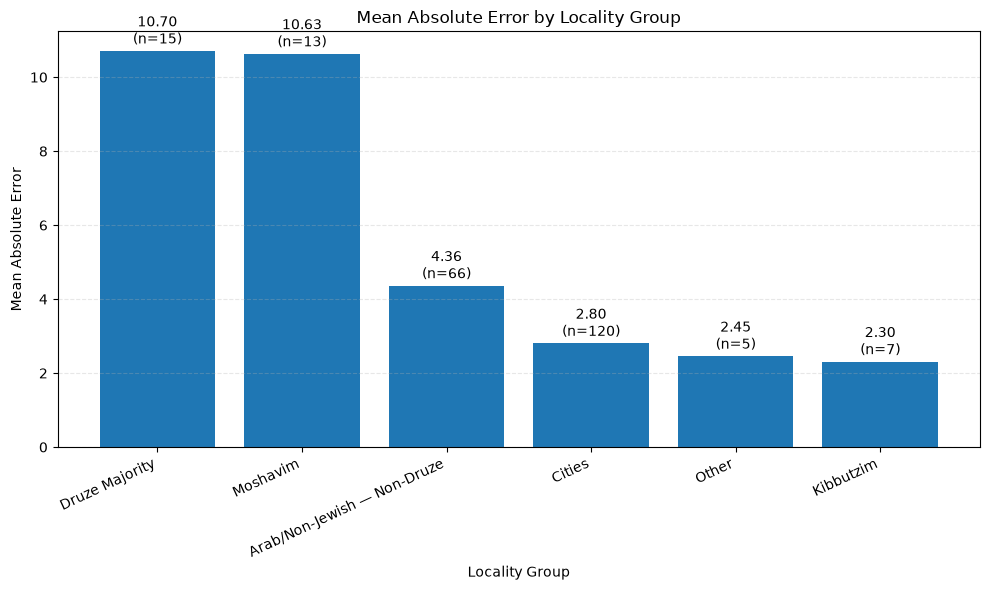

In [14]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    group_error_summary["Analysis_Group"],
    group_error_summary["Mean_MAE"]
)

plt.title("Mean Absolute Error by Locality Group")
plt.xlabel("Locality Group")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=25, ha="right")

for bar, mae_value, count in zip(
    bars,
    group_error_summary["Mean_MAE"],
    group_error_summary["Number_of_Localities"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.08,
        f"{mae_value:.2f}\n(n={int(count)})",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "mae_by_locality_group.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


## 8. Error by locality group and voting block

In [15]:
group_target_rows = []

for group_name, group_data in error_df.groupby(
    "Analysis_Group"
):
    row = {
        "Analysis_Group": group_name,
        "Number_of_Rows": len(group_data),
        "Number_of_Localities": (
            group_data["locality_symbol"]
            .nunique()
        ),
    }

    for target in TARGET_COLUMNS:
        row[f"MAE_{target}"] = (
            group_data[
                f"Absolute_Error_{target}"
            ]
            .mean()
        )

    group_target_rows.append(row)

group_target_summary = (
    pd.DataFrame(
        group_target_rows
    )
    .sort_values(
        "MAE_Right_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    group_target_summary
    .round(3)
)


,Analysis_Group,Number_of_Rows,Number_of_Localities,MAE_Right_pct,MAE_Center_Left_pct,MAE_Haredi_pct,MAE_Arab_pct
0,Druze Majority,15,15,18.634,15.299,2.003,6.880
1,Moshavim,13,13,15.188,18.100,8.977,0.243
2,Cities,120,120,4.540,3.660,2.444,0.558
3,Arab/Non-Jewish — Non-Druze,66,66,4.333,5.082,0.549,7.469
4,Kibbutzim,7,7,3.829,4.370,0.405,0.614
5,Other,5,5,3.448,3.952,1.927,0.477


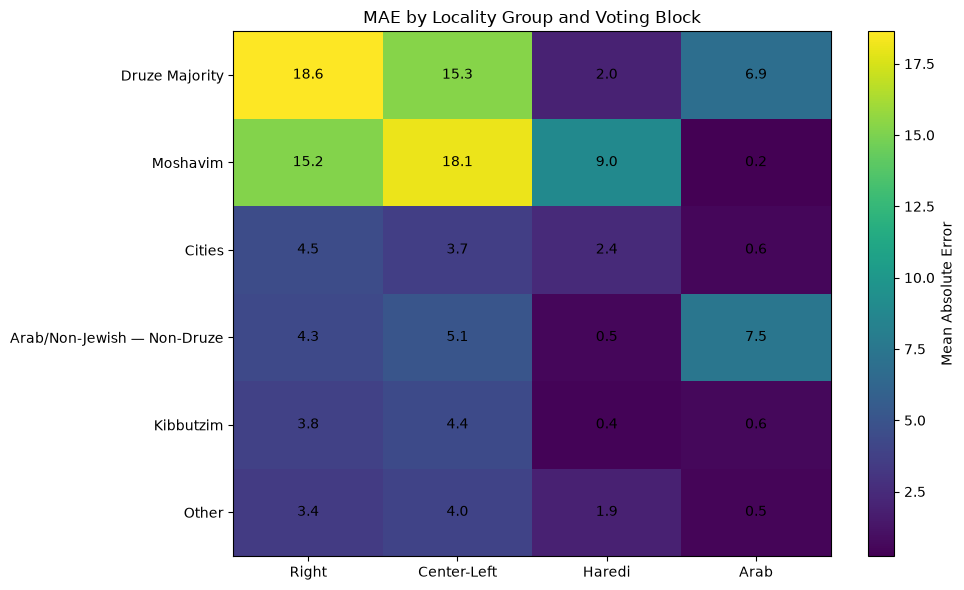

In [16]:
group_target_columns = [
    f"MAE_{target}"
    for target in TARGET_COLUMNS
]

heatmap_values = (
    group_target_summary[
        group_target_columns
    ]
    .to_numpy(dtype=float)
)

plt.figure(figsize=(10, 6))

image = plt.imshow(
    heatmap_values,
    aspect="auto"
)

plt.colorbar(
    image,
    label="Mean Absolute Error"
)

plt.xticks(
    range(len(TARGET_COLUMNS)),
    [
        TARGET_LABELS[target]
        for target in TARGET_COLUMNS
    ]
)

plt.yticks(
    range(len(group_target_summary)),
    group_target_summary["Analysis_Group"]
)

for row_index in range(
    heatmap_values.shape[0]
):
    for column_index in range(
        heatmap_values.shape[1]
    ):
        plt.text(
            column_index,
            row_index,
            f"{heatmap_values[row_index, column_index]:.1f}",
            ha="center",
            va="center"
        )

plt.title("MAE by Locality Group and Voting Block")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "group_target_error_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


## 9. Top 10 localities with the highest prediction error

In [17]:
top_10_errors = (
    error_df
    .sort_values(
        "Mean_Absolute_Error",
        ascending=False
    )
    .head(10)
    .copy()
)

top_10_summary_columns = [
    locality_name_column,
    "Analysis_Group",
    "Mean_Absolute_Error",
    "Largest_Error_Target",
    "Maximum_Error",
]

display(
    top_10_errors[
        top_10_summary_columns
    ]
    .round(3)
)


,שם יישוב,Analysis_Group,Mean_Absolute_Error,Largest_Error_Target,Maximum_Error
73,בת שלמה,Moshavim,27.297,Center_Left_pct,53.999
27,חצבה,Moshavim,26.191,Center_Left_pct,51.165
39,שדה משה,Moshavim,23.765,Center_Left_pct,47.530
101,מסעדה,Druze Majority,21.691,Arab_pct,43.383
72,עוצם,Moshavim,20.045,Haredi_pct,40.089
141,סאג'ור,Druze Majority,19.678,Right_pct,39.356
103,ע'ג'ר,Arab/Non-Jewish — Non-Druze,19.678,Right_pct,38.851
26,כסרא-סמיע,Druze Majority,18.632,Right_pct,34.278
104,עין קנייא,Druze Majority,15.451,Right_pct,30.866
219,טובא-זנגרייה,Arab/Non-Jewish — Non-Druze,12.343,Arab_pct,24.686


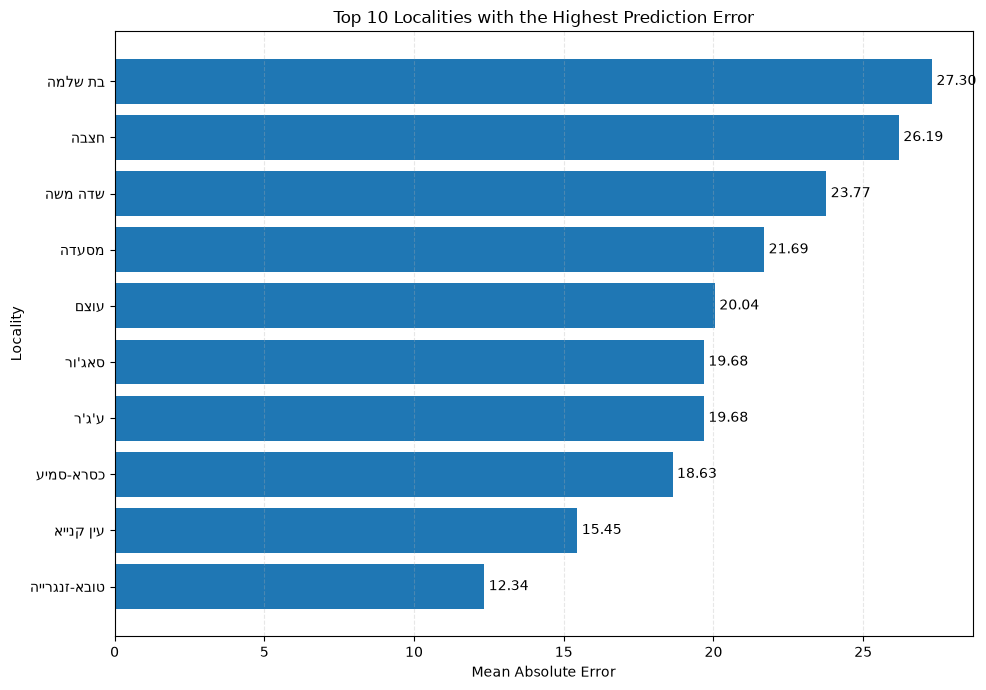

In [18]:
top_10_for_chart = (
    top_10_errors
    .sort_values(
        "Mean_Absolute_Error",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_10_for_chart[
        locality_name_column
    ],
    top_10_for_chart[
        "Mean_Absolute_Error"
    ]
)

plt.title(
    "Top 10 Localities with the Highest Prediction Error"
)
plt.xlabel("Mean Absolute Error")
plt.ylabel("Locality")

for bar, value in zip(
    bars,
    top_10_for_chart[
        "Mean_Absolute_Error"
    ]
):
    plt.text(
        value + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center"
    )

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "top_10_locality_errors.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


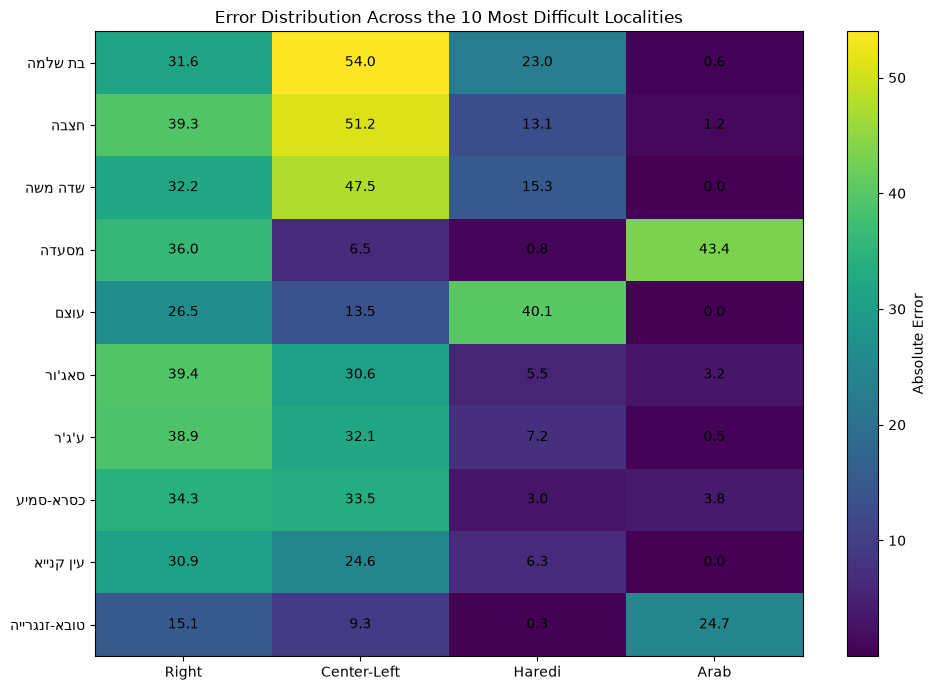

In [19]:
top_10_error_values = (
    top_10_errors[
        ABSOLUTE_ERROR_COLUMNS
    ]
    .to_numpy(dtype=float)
)

plt.figure(figsize=(10, 7))

image = plt.imshow(
    top_10_error_values,
    aspect="auto"
)

plt.colorbar(
    image,
    label="Absolute Error"
)

plt.xticks(
    range(len(TARGET_COLUMNS)),
    [
        TARGET_LABELS[target]
        for target in TARGET_COLUMNS
    ]
)

plt.yticks(
    range(len(top_10_errors)),
    top_10_errors[
        locality_name_column
    ]
)

for row_index in range(
    top_10_error_values.shape[0]
):
    for column_index in range(
        top_10_error_values.shape[1]
    ):
        plt.text(
            column_index,
            row_index,
            f"{top_10_error_values[row_index, column_index]:.1f}",
            ha="center",
            va="center"
        )

plt.title(
    "Error Distribution Across the 10 Most Difficult Localities"
)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "top_10_error_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


## 10. Detailed direction of error in the 10 most difficult localities

In [20]:
for rank, (_, row) in enumerate(
    top_10_errors.iterrows(),
    start=1
):
    print(
        f"\n{rank}. "
        f"{row[locality_name_column]}"
    )

    print(
        f"Group: {row['Analysis_Group']}"
    )

    print(
        f"Mean absolute error: "
        f"{row['Mean_Absolute_Error']:.2f}"
    )

    print(
        f"Largest error: "
        f"{row['Largest_Error_Target']} "
        f"({row['Maximum_Error']:.2f})"
    )

    print("-" * 105)

    for target in TARGET_COLUMNS:
        actual = row[target]
        predicted = row[
            f"Predicted_{target}"
        ]
        signed_error = row[
            f"Signed_Error_{target}"
        ]
        absolute_error = row[
            f"Absolute_Error_{target}"
        ]

        if signed_error > 0:
            direction = "overprediction"
        elif signed_error < 0:
            direction = "underprediction"
        else:
            direction = "exact prediction"

        print(
            f"{target:<20} | "
            f"Actual: {actual:>6.2f} | "
            f"Predicted: {predicted:>6.2f} | "
            f"Error: {absolute_error:>6.2f} | "
            f"{direction}"
        )



1. בת שלמה
Group: Moshavim
Mean absolute error: 27.30
Largest error: Center_Left_pct (54.00)
---------------------------------------------------------------------------------------------------------
Right_pct            | Actual:  23.89 | Predicted:  55.50 | Error:  31.61 | overprediction
Center_Left_pct      | Actual:  74.52 | Predicted:  20.52 | Error:  54.00 | underprediction
Haredi_pct           | Actual:   0.96 | Predicted:  23.94 | Error:  22.98 | overprediction
Arab_pct             | Actual:   0.64 | Predicted:   0.04 | Error:   0.59 | underprediction

2. חצבה
Group: Moshavim
Mean absolute error: 26.19
Largest error: Center_Left_pct (51.17)
---------------------------------------------------------------------------------------------------------
Right_pct            | Actual:  12.75 | Predicted:  52.06 | Error:  39.31 | overprediction
Center_Left_pct      | Actual:  84.75 | Predicted:  33.58 | Error:  51.17 | underprediction
Haredi_pct           | Actual:   1.25 | Predicted:  14

## 11. Optional weighted evaluation by valid votes

ה־MAE הרגיל נותן משקל זהה לכל יישוב.

כאשר המטרה היא להעריך את ההשפעה על התוצאה הכוללת, אפשר לחשב גם MAE משוקלל לפי מספר הקולות הכשרים. כך שגיאה בעיר גדולה מקבלת משקל גדול יותר משגיאה ביישוב קטן.


In [21]:
weighted_results = None

if "valid_votes" in error_df.columns:
    error_df["valid_votes"] = pd.to_numeric(
        error_df["valid_votes"],
        errors="coerce"
    )

    valid_weight_rows = (
        error_df["valid_votes"].notna()
        & error_df["valid_votes"].gt(0)
    )

    if valid_weight_rows.any():
        weighted_data = error_df.loc[
            valid_weight_rows
        ]

        weights = weighted_data[
            "valid_votes"
        ].to_numpy(dtype=float)

        weighted_overall_mae = np.average(
            weighted_data[
                "Mean_Absolute_Error"
            ],
            weights=weights
        )

        weighted_target_rows = []

        for target in TARGET_COLUMNS:
            weighted_target_mae = np.average(
                weighted_data[
                    f"Absolute_Error_{target}"
                ],
                weights=weights
            )

            weighted_target_rows.append({
                "Target": target,
                "Weighted_MAE": weighted_target_mae,
            })

        weighted_results = pd.DataFrame(
            weighted_target_rows
        )

        print(
            f"Vote-weighted overall MAE: "
            f"{weighted_overall_mae:.3f}"
        )

        display(
            weighted_results
            .round(3)
        )
    else:
        print(
            "No valid positive vote weights were found."
        )
else:
    print(
        "The valid_votes column is not available. "
        "Weighted evaluation was skipped."
    )


Vote-weighted overall MAE: 2.723


,Target,Weighted_MAE
0,Right_pct,4.024
1,Center_Left_pct,3.102
2,Haredi_pct,2.398
3,Arab_pct,1.368


## 12. Final evaluation summary

In [22]:
actual_array = (
    error_df[TARGET_COLUMNS]
    .to_numpy(dtype=float)
)

predicted_array = (
    error_df[PREDICTED_COLUMNS]
    .to_numpy(dtype=float)
)

recalculated_overall_mae = mean_absolute_error(
    actual_array,
    predicted_array
)

recalculated_overall_r2 = r2_score(
    actual_array,
    predicted_array
)

recalculated_target_mae = mean_absolute_error(
    actual_array,
    predicted_array,
    multioutput="raw_values"
)

recalculated_target_r2 = r2_score(
    actual_array,
    predicted_array,
    multioutput="raw_values"
)

evaluation_summary_df = pd.DataFrame({
    "Metric": [
        "Overall_MAE",
        "Overall_R2",
        *[
            f"MAE_{target}"
            for target in TARGET_COLUMNS
        ],
        *[
            f"R2_{target}"
            for target in TARGET_COLUMNS
        ],
    ],
    "Value": [
        recalculated_overall_mae,
        recalculated_overall_r2,
        *recalculated_target_mae,
        *recalculated_target_r2,
    ],
})

display(
    evaluation_summary_df
    .round(4)
)

print(
    f"Overall MAE: "
    f"{recalculated_overall_mae:.3f}"
)
print(
    f"Overall R2: "
    f"{recalculated_overall_r2:.3f}"
)


,Metric,Value
0,Overall_MAE,4.2070
1,Overall_R2,0.9156
2,MAE_Right_pct,5.9815
3,MAE_Center_Left_pct,5.7066
4,MAE_Haredi_pct,2.1625
5,MAE_Arab_pct,2.9775
6,R2_Right_pct,0.8603
7,R2_Center_Left_pct,0.8872
8,R2_Haredi_pct,0.9371
9,R2_Arab_pct,0.9779


Overall MAE: 4.207
Overall R2: 0.916


## 13. Save evaluation outputs

In [23]:
evaluation_summary_df.to_csv(
    EVALUATION_SUMMARY_CSV_PATH,
    index=False,
    encoding="utf-8-sig"
)

error_df.to_csv(
    LOCALITY_ERROR_PATH,
    index=False,
    encoding="utf-8-sig"
)

group_error_summary.to_csv(
    GROUP_ERROR_PATH,
    index=False,
    encoding="utf-8-sig"
)

group_target_summary.to_csv(
    GROUP_TARGET_ERROR_PATH,
    index=False,
    encoding="utf-8-sig"
)

evaluation_summary_json = {
    "selected_model": selected_model_name,
    "validation_election": modeling_summary[
        "validation_election"
    ],
    "validation_rows": int(len(error_df)),
    "overall_mae": float(
        recalculated_overall_mae
    ),
    "overall_r2": float(
        recalculated_overall_r2
    ),
    "target_results": {
        target: {
            "mae": float(mae_value),
            "r2": float(r2_value),
        }
        for target, mae_value, r2_value in zip(
            TARGET_COLUMNS,
            recalculated_target_mae,
            recalculated_target_r2
        )
    },
    "prediction_sum_minimum": float(
        error_df["Predicted_Total"].min()
    ),
    "prediction_sum_maximum": float(
        error_df["Predicted_Total"].max()
    ),
    "highest_error_locality": str(
        top_10_errors.iloc[0][
            locality_name_column
        ]
    ),
    "highest_locality_mean_absolute_error": float(
        top_10_errors.iloc[0][
            "Mean_Absolute_Error"
        ]
    ),
    "group_with_highest_mean_mae": str(
        group_error_summary.iloc[0][
            "Analysis_Group"
        ]
    ),
    "highest_group_mean_mae": float(
        group_error_summary.iloc[0][
            "Mean_MAE"
        ]
    ),
    "weighted_evaluation_available": bool(
        weighted_results is not None
    ),
}

if weighted_results is not None:
    evaluation_summary_json[
        "vote_weighted_overall_mae"
    ] = float(weighted_overall_mae)

    evaluation_summary_json[
        "vote_weighted_target_mae"
    ] = {
        row["Target"]: float(
            row["Weighted_MAE"]
        )
        for _, row in weighted_results.iterrows()
    }

with open(
    EVALUATION_SUMMARY_JSON_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        evaluation_summary_json,
        file,
        ensure_ascii=False,
        indent=2
    )

print("Evaluation artifacts saved:")
print(f"- {EVALUATION_SUMMARY_CSV_PATH}")
print(f"- {LOCALITY_ERROR_PATH}")
print(f"- {GROUP_ERROR_PATH}")
print(f"- {GROUP_TARGET_ERROR_PATH}")
print(f"- {EVALUATION_SUMMARY_JSON_PATH}")
print(f"- Figures directory: {FIGURES_DIR}")


Evaluation artifacts saved:
- ..\reports\evaluation_summary.csv
- ..\reports\error_analysis_by_locality.csv
- ..\reports\error_summary_by_group.csv
- ..\reports\error_summary_by_group_and_target.csv
- ..\reports\evaluation_summary.json
- Figures directory: ..\reports\figures


## 14. Conclusions and limitations

### Key Findings

*   Model Composition: The selected model combines a CLR transformation with segmentation between Arab/Non-Jewish localities and all other localities.
*   CLR Transformation: Ensures that all predictions are positive and sum to exactly 100%.
*   Error Distribution: Errors are not uniformly distributed; accuracy is highest in cities and lowest in Druze-majority localities and moshavim.
*   Primary Challenge: The main remaining challenge is distinguishing between the Right and Center-Left blocs.
*   Comprehensive Analysis: Error analysis provides complementary insights, preventing over-reliance on aggregated metrics like MAE and R².

### Limitations

*   Test Discipline: Knesset 25 was excluded from every modeling decision and evaluated exactly once; the reported metrics are honest but rest on a single test election.
*   Coverage: Only the 226 localities with CBS profiles are modeled (~82% of national valid votes); small localities are underrepresented.
*   Demographic Snapshots: Annual data cannot separate the two 2019 election cycles, and CBS reporting coverage itself drifts between years.
*   External Factors: The model does not account for political or security events, party alliances, shifts in voter turnout, or the entry of new candidates.
*   Anomalous Patterns: Model performance is weaker in localities with idiosyncratic local political patterns.

### Next Steps

*   Retrain the selected architecture on all available election cycles, including 2022.
*   Feed in the most recent demographic data (the LOCF step already handles partial coverage).
*   Generate a single forecast per locality and evaluate the national weighted outcome.
*   Add a previous-election baseline and rolling leave-one-election-out validation.
